In [1]:
!apt-get update && apt-get install -y ffmpeg
import os
import numpy as np
# import pandas as pd
import time
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib as mpl
import matplotlib.pyplot as plt
import random

# Check if TPU is available
is_tpu = False
try:
    import torch_xla.core.xla_model as xm
    device = xm.xla_device()
    is_tpu = True
    print("TPU is available and initialized.")
except ImportError:
    # If TPU not available, check for GPU
    if torch.cuda.is_available():
        device = torch.device("cuda")
        print("GPU is available and initialized.")
    else:
        device = torch.device("cpu")
        print("CPU is available and initialized.")

print(f"Using device: {device}")

# Initial bias as 0 for NNs, created on the selected device
bias_initializer = torch.tensor([0.0], device=device)

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:4 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [6529 kB]
Get:5 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4070 kB]
Get:7 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3734 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates/multiverse amd64 Packages [70.9 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd64 Packages [6749 kB]
Get:10 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1301 kB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/multiverse amd64 Packages [62.6 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1614 kB]
Get:13 http://arch

In [2]:
def create_tensors_2D(nx, ny):
    input_shape = (1, 1, ny, nx)
    input_shape_pad = (1, 1, ny + 2, nx + 2)
    values_u = torch.zeros(input_shape, device=device)
    values_v = torch.zeros(input_shape, device=device)
    values_p = torch.zeros(input_shape, device=device)
    values_uu = torch.zeros(input_shape_pad, device=device)
    values_vv = torch.zeros(input_shape_pad, device=device)
    values_pp = torch.zeros(input_shape_pad, device=device)
    b_uu = torch.zeros(input_shape_pad, device=device)
    b_vv = torch.zeros(input_shape_pad, device=device)
    print('All the required 2D tensors have been created successfully!')
    print('===========================================================')
    print('values_u  => u velocity [first step]  - (1,1,ny,nx)')
    print('values_v  => v velocity [first step]  - (1,1,ny,nx)')
    print('values_p  => pressure                 - (1,1,ny,nx)')
    print('b_uu      => v velocity [second step] - (1,1,ny+2,nx+2)')
    print('b_vv      => v velocity [second step] - (1,1,ny+2,nx+2)')
    print('values_uu => u velocity [first step]  - (1,1,ny+2,nx+2)')
    print('values_vv => v velocity [first step]  - (1,1,ny+2,nx+2)')
    print('values_pp => pressure                 - (1,1,ny+2,nx+2)')
    print('===========================================================')
    return values_u, values_v, values_p, values_uu, values_vv, values_pp, b_uu, b_vv

def get_weights_linear_2D(dx):
    w1 = torch.tensor([[[[1/3/dx**2],
             [1/3/dx**2],
             [1/3/dx**2]],

            [[1/3/dx**2],
             [-8/3/dx**2],
             [1/3/dx**2]],

            [[1/3/dx**2],
             [1/3/dx**2],
             [1/3/dx**2]]]])

    w2 = torch.tensor([[[[1/(12*dx)],  # Central differencing for y-advection and second-order time scheme
             [0.0],
             [-1/(12*dx)]],

            [[1/(3*dx)],
             [0.0],
             [-1/(3*dx)]],

            [[1/(12*dx)],
             [0.0],
             [-1/(12*dx)]]]])

    w3 = torch.tensor([[[[-1/(12*dx)],  # Central differencing for y-advection and second-order time scheme
             [-1/(3*dx)],
             [-1/(12*dx)]],

            [[0.0],
             [0.0],
             [0.0]],

            [[1/(12*dx)],
             [1/(3*dx)],
             [1/(12*dx)]]]])

    wA = torch.tensor([[[[-1/3/dx**2],  # A matrix for Jacobi
             [-1/3/dx**2],
             [-1/3/dx**2]],

            [[-1/3/dx**2],
             [8/3/dx**2],
             [-1/3/dx**2]],

            [[-1/3/dx**2],
             [-1/3/dx**2],
             [-1/3/dx**2]]]])

    w1 = torch.reshape(w1, (1,1,3,3))
    w2 = torch.reshape(w2, (1,1,3,3))
    w3 = torch.reshape(w3, (1,1,3,3))
    wA = torch.reshape(wA, (1,1,3,3))
    w_res = torch.zeros([1,1,2,2])
    w_res[0,0,:,:] = 0.25
    diag = np.array(wA)[0,0,1,1]        # Diagonal component
    print('All the required 2D filters have been created successfully!')
    print('===========================================================')
    print('w1    => second order derivative  - (1,1,3,3)')
    print('w2    => first order derivative x - (1,1,3,3)')
    print('w3    => first order derivative y - (1,1,3,3)')
    print('wA    => second order derivative  - (1,1,3,3)')
    print('w_res => Restriction operation    - (1,1,3,3)')
    print('diag  => Diagonal component of wA - (1,1,1,1)')
    print('===========================================================')
    return w1, w2, w3, wA, w_res, diag

In [3]:
# def boundary_condition_2D_u(values_u, values_uu, ub):
# 	ny = values_u.shape[2]
# 	nx = values_u.shape[3]
# 	nny = values_uu.shape[2]
# 	nnx = values_uu.shape[3]

# 	values_uu[0,0,1:nny-1,1:nnx-1] = values_u[0,0,:,:]
# 	values_uu[0,0,:,0].fill_(ub)
# 	values_uu[0,0,:,nx+1].fill_(ub)
# 	values_uu[0,0,0,:].fill_(0.0)
# 	values_uu[0,0,ny+1,:].fill_(0.0)
# 	return values_uu

# def boundary_condition_2D_v(values_v, values_vv, ub):
# 	ny = values_v.shape[2]
# 	nx = values_v.shape[3]
# 	nny = values_vv.shape[2]
# 	nnx = values_vv.shape[3]

# 	values_vv[0,0,1:nny-1,1:nnx-1] = values_v[0,0,:,:]
# 	values_vv[0,0,:,0].fill_(0.0)
# 	values_vv[0,0,:,nx+1].fill_(0.0)
# 	values_vv[0,0,0,:].fill_(0.0)
# 	values_vv[0,0,ny+1,:].fill_(0.0)
# 	return values_vv


# def boundary_condition_2D_p(values_p, values_pp):
# 	ny = values_p.shape[2]
# 	nx = values_p.shape[3]
# 	nny = values_pp.shape[2]
# 	nnx = values_pp.shape[3]

# 	values_pp[0,0,1:nny-1,1:nnx-1] = values_p[0,0,:,:]
# 	values_pp[0,0,:,0] =  values_pp[0,0,:,1]
# 	values_pp[0,0,:,nx+1] = values_pp[0,0,:,nx]*0
# 	values_pp[0,0,0,:] = values_pp[0,0,1,:]
# 	values_pp[0,0,ny+1,:] = values_pp[0,0,ny,:]
# 	return values_pp

def boundary_condition_2D_u(values_u, values_uu, ub):
    ny, nx = values_u.shape[2], values_u.shape[3]
    values_uu[..., 1:ny+1, 1:nx+1] = values_u[..., :, :]

    # Top/bottom infilite: u=0
    values_uu[..., 0, :] = values_uu[..., 1, :]#0.0
    values_uu[..., ny+1, :] = values_uu[..., ny, :]#0.0

    # Left boundary: set to inflow speed (-ub for left-to-right flow, as ub is -1.0)
    values_uu[..., :, 0] = ub
    # Right boundary: zero-gradient (outflow)
    values_uu[..., :, nx+1] = values_uu[..., :, nx]
    return values_uu

def boundary_condition_2D_v(values_v, values_vv, ub):
    ny, nx = values_v.shape[2], values_v.shape[3]
    values_vv[..., 1:ny+1, 1:nx+1] = values_v[..., :, :]

    # Top/bottom no-slip: v=0
    values_vv[..., 0, :] = values_vv[..., 0, :]#0.0
    values_vv[..., ny+1, :] = values_vv[..., ny, :]#0.0

    # Left/right open: often dv/dx=0 (zeroGradient)
    values_vv[..., :, 0] = values_vv[..., :, 1]
    values_vv[..., :, nx+1] = values_vv[..., :, nx]
    return values_vv

def boundary_condition_2D_p(values_p, values_pp):
    ny, nx = values_p.shape[2], values_p.shape[3]
    values_pp[..., 1:ny+1, 1:nx+1] = values_p[..., :, :]

    #Left/right: dp/dx=0e
    values_pp[..., :, 0] = values_pp[..., :, 1]
    values_pp[..., :, nx+1] = values_pp[..., :, nx]

    #Top/bottom: choose something consistent (common: dp/dy=0 too in many cavity-like setups)
    values_pp[..., 0, :] = values_pp[..., 1, :]
    values_pp[..., ny+1, :] = values_pp[..., ny, :]
    return values_pp

def boundary_condition_2D_cw(w):
	ny = w.shape[2]
	nx = w.shape[3]
	ww = F.pad(w, (1, 1, 1, 1), mode='constant', value=0)
	ww[0,0,:,0] =  ww[0,0,:,1]*0
	ww[0,0,:,nx+1] = ww[0,0,:,nx]*0
	ww[0,0,0,:] = ww[0,0,1,:]*0
	ww[0,0,ny+1,:] = ww[0,0,ny,:]*0
	return ww

In [4]:
def create_circle(nx, ny, cor_x, cor_y, radius):
    input_shape = (1, 1, ny, nx)
    sigma = torch.zeros(input_shape, device=device)
    y_indices, x_indices = torch.meshgrid(torch.arange(ny), torch.arange(nx), indexing='ij')
    distance_squared = (x_indices - cor_x)**2 + (y_indices - cor_y)**2
    mask = distance_squared <= radius**2
    sigma[0, 0, mask] = 1e08
    print('A circular bluff body has been created successfully!')
    print('===================================================')
    print('Radius of circle:', radius)
    print('Position of circle in x:', cor_x)
    print('Position of circle in y:', cor_y)
    print('===================================================')
    return sigma

def create_solid_body_2D(nx, ny, cor_x, cor_y, size_x, size_y):
    input_shape = (1, 1, ny, nx)
    sigma = torch.zeros(input_shape, device=device)
    sigma[0,0,cor_y-size_y:cor_y+size_y,cor_x-size_x:cor_x+size_x] = 1e08
    print('A bluff body has been created successfully!')
    print('===========================================')
    print('Size of body in x:',size_x*2)
    print('Size of body in y:',size_y*2)
    print('position of body in x:',cor_x)
    print('position of body in y:',cor_y)
    print('===========================================')
    return sigma

def create_ellipse(nx,ny,cor_x,cor_y,radius_1,radius_2):
    input_shape = (1, 1, ny, nx)
    sigma = torch.zeros(input_shape, device=device)
    y_indices, x_indices = torch.meshgrid(torch.arange(ny,device=device), torch.arange(nx,device=device), indexing='ij')
    distance_squared = ((x_indices - cor_x) / radius_1)**2 + ((y_indices - cor_y) / radius_2)**2
    mask = distance_squared <= 1
    sigma[0, 0, mask] = 1e08
    print('A elliptical bluff body has been created successfully!')
    print('===================================================')
    print('Radius 1 of ellipse:', radius_1)
    print('Radius 2 of ellipse:', radius_2)
    print('Position of ellipse in x:', cor_x)
    print('Position of ellipse in y:', cor_y)
    print('===================================================')
    return sigma

def area(x1, y1, x2, y2, x3, y3):
    # Python's native abs() works on both floats and Tensors
    return abs((x1 * (y2 - y3) + x2 * (y3 - y1) + x3 * (y1 - y2)) / 2.0)

def create_triangle(nx, ny, cor_x, cor_y, radius):
    # --- 1. Define Vertices (Corrected) ---
    # Top vertex
    x1 = cor_x - radius
    y1 = cor_y
    
    # Bottom right vertex (cos(30) ~ 0.866)
    x2 = cor_x + 0.5 * radius
    y2 = cor_y + 0.86602540378 * radius
    
    # Bottom left vertex
    x3 = cor_x + 0.5 * radius
    y3 = cor_y - 0.86602540378 * radius

    # --- 2. Create Grid ---
    # y varies down rows, x varies across columns
    y_indices, x_indices = torch.meshgrid(torch.arange(ny,device=device), 
                                          torch.arange(nx,device=device), 
                                          indexing='ij')
    
    # --- 3. Vectorized Area Calculation ---
    # Total area of the main triangle (Scalar)
    A = area(x1, y1, x2, y2, x3, y3)
    
    # Area of sub-triangles formed with the grid points (Tensors)
    # We pass the entire grid (x_indices, y_indices) as the test point (x, y)
    A1 = area(x_indices, y_indices, x2, y2, x3, y3)
    A2 = area(x1, y1, x_indices, y_indices, x3, y3)
    A3 = area(x1, y1, x2, y2, x_indices, y_indices)
    
    # --- 4. Create Mask ---
    # Check if Sum of areas == Total Area. 
    # We use a small epsilon (1e-5) because float math is rarely exact.
    epsilon = 1e-4
    mask = torch.abs((A1 + A2 + A3) - A) < epsilon

    input_shape = (1, 1, ny, nx)
    sigma = torch.zeros(input_shape, device=device)
    sigma[0, 0, mask] = 1e08
    
    return sigma

In [5]:
dt = 0.05                               # Time step (s)
dx = 1.0 ; dy = 1.0                     # Grid size (m)
nu = 0.05                               # Viscosity coefficient
ub = -1.2                               # Inflow speed (m/s)
nx = 512 ; ny = 256                     # Grid point (reduced for speed)
lx = dx * nx ; ly = dy * ny             # Domain size (m)
nlevel = int(math.log(ny, 2)) + 1       # Multigrid level
ntime = 100000                           # Time step (reduced for speed)
n_out = 20                              # Time step to save results
n_check = 100                           # Time step to check residual
iteration = 3                           # Multigrid iteration (reduced for speed)
filepath = 'data'                       # filepath to save results
T_stat = True                           # Generate time histories at specific points
L_save = True                           # Save results
bias_initializer = torch.tensor([0.0])  # Initial bias as 0 for NNs

In [6]:
if not os.path.exists(filepath):
    os.makedirs(filepath)

In [7]:
[w1, w2, w3, wA, w_res, diag] = get_weights_linear_2D(dx)

All the required 2D filters have been created successfully!
w1    => second order derivative  - (1,1,3,3)
w2    => first order derivative x - (1,1,3,3)
w3    => first order derivative y - (1,1,3,3)
wA    => second order derivative  - (1,1,3,3)
w_res => Restriction operation    - (1,1,3,3)
diag  => Diagonal component of wA - (1,1,1,1)


In [8]:
class AI4CFD(nn.Module):
    """docstring for AI4CFD"""
    def __init__(self):
        super(AI4CFD, self).__init__()
        # self.arg = arg
        self.xadv = nn.Conv2d(1, 1, kernel_size=3, stride=1, padding=0)
        self.yadv = nn.Conv2d(1, 1, kernel_size=3, stride=1, padding=0)
        self.diff = nn.Conv2d(1, 1, kernel_size=3, stride=1, padding=0)
        self.A = nn.Conv2d(1, 1, kernel_size=3, stride=1, padding=0)
        self.res = nn.Conv2d(1, 1, kernel_size=2, stride=2, padding=0)
        self.prol = nn.Sequential(nn.Upsample(scale_factor=2, mode='nearest'),)

        self.xadv.weight.data = w2
        self.yadv.weight.data = w3
        self.diff.weight.data = w1
        self.A.weight.data = wA
        self.res.weight.data = w_res

        self.xadv.bias.data = bias_initializer
        self.yadv.bias.data = bias_initializer
        self.diff.bias.data = bias_initializer
        self.A.bias.data = bias_initializer
        self.res.bias.data = bias_initializer

    def solid_body(self, values_u, values_v, sigma, dt):
        values_u = values_u / (1 + dt * sigma)
        values_v = values_v / (1 + dt * sigma)
        return values_u, values_v

    def F_cycle_MG(self, values_uu, values_vv, values_p, values_pp, iteration, diag, dt, nlevel):
        b = -(self.xadv(values_uu) + self.yadv(values_vv)) / dt
        for MG in range(iteration):
            w = torch.zeros((1,1,1,1), device=device)
            r = self.A(boundary_condition_2D_p(values_p, values_pp)) - b
            r_s = []
            r_s.append(r)
            for i in range(1,nlevel):
                r = self.res(r)
                r_s.append(r)
            for i in reversed(range(1,nlevel)):
                ww = boundary_condition_2D_cw(w)
                w = w - self.A(ww) / diag + r_s[i] / diag
                w = self.prol(w)
            values_p = values_p - w
            values_p = values_p - self.A(boundary_condition_2D_p(values_p, values_pp)) / diag + b / diag
        return values_p, w, r

    def forward(self, values_u, values_uu, values_v, values_vv, values_p, values_pp, sigma, b_uu, b_vv, dt, iteration):
        values_uu = boundary_condition_2D_u(values_u,values_uu,ub)
        values_vv = boundary_condition_2D_v(values_v,values_vv,ub)
        values_pp = boundary_condition_2D_p(values_p,values_pp)
        Grapx_p  = self.xadv(values_pp) * dt  ; Grapy_p = self.yadv(values_pp) * dt
        ADx_u = self.xadv(values_uu) ; ADy_u = self.yadv(values_uu)
        ADx_v = self.xadv(values_vv) ; ADy_v = self.yadv(values_vv)
        AD2_u = self.diff(values_uu) ; AD2_v = self.diff(values_vv)
    # First step for solving uvw
        b_u = values_u + 0.5 * (nu * AD2_u * dt - values_u * ADx_u * dt - values_v * ADy_u * dt) - Grapx_p
        b_v = values_v + 0.5 * (nu * AD2_v * dt - values_u * ADx_v * dt - values_v * ADy_v * dt) - Grapy_p
        [b_u, b_v] = self.solid_body(b_u, b_v, sigma, dt)
    # Padding velocity vectors
        b_uu = boundary_condition_2D_u(b_u,b_uu,ub)
        b_vv = boundary_condition_2D_v(b_v,b_vv,ub)
        ADx_u = self.xadv(b_uu) ; ADy_u = self.yadv(b_uu)
        ADx_v = self.xadv(b_vv) ; ADy_v = self.yadv(b_vv)
        AD2_u = self.diff(b_uu) ; AD2_v = self.diff(b_vv)
    # Second step for solving uvw
        values_u = values_u + nu * AD2_u * dt - b_u * ADx_u * dt - b_v * ADy_u * dt - Grapx_p
        values_v = values_v + nu * AD2_v * dt - b_u * ADx_v * dt - b_v * ADy_v * dt - Grapy_p
        [values_u, values_v] = self.solid_body(values_u, values_v, sigma, dt)
    # pressure
        values_uu = boundary_condition_2D_u(values_u,values_uu,ub)
        values_vv = boundary_condition_2D_v(values_v,values_vv,ub)
        [values_p, w ,r] = self.F_cycle_MG(values_uu, values_vv, values_p, values_pp, iteration, diag, dt, nlevel)
    # Pressure gradient correction
        values_pp = boundary_condition_2D_p(values_p, values_pp)
        values_u = values_u - self.xadv(values_pp) * dt ; values_v = values_v - self.yadv(values_pp) * dt
        [values_u, values_v] = self.solid_body(values_u, values_v, sigma, dt)
        return values_u, values_v, values_p, w, r

In [9]:
AI4CFD = AI4CFD().to(device)

In [10]:
values_u, values_v, values_p, values_uu, values_vv, values_pp, b_uu, b_vv = create_tensors_2D(nx, ny)
values_u = values_u.to(device)
values_v = values_v.to(device)
values_p = values_p.to(device)
values_uu = values_uu.to(device)
values_vv = values_vv.to(device)
values_pp = values_pp.to(device)
b_uu = b_uu.to(device)
b_vv = b_vv.to(device)

All the required 2D tensors have been created successfully!
values_u  => u velocity [first step]  - (1,1,ny,nx)
values_v  => v velocity [first step]  - (1,1,ny,nx)
values_p  => pressure                 - (1,1,ny,nx)
b_uu      => v velocity [second step] - (1,1,ny+2,nx+2)
b_vv      => v velocity [second step] - (1,1,ny+2,nx+2)
values_uu => u velocity [first step]  - (1,1,ny+2,nx+2)
values_vv => v velocity [first step]  - (1,1,ny+2,nx+2)
values_pp => pressure                 - (1,1,ny+2,nx+2)


In [11]:
values_u[:] = 0.1*torch.randn(1,1,ny,nx)

In [12]:
# Fixed-size grid of cubes with one-cube spacing (edge-to-edge gap = cube_size)
# Configuration (change these values as needed)
n_cols = 2    # number of columns (3 for a 2x3 layout with n_rows=2)
n_rows = 3    # number of rows
cor_x = int(nx/4)
cor_y = int(ny/2)
cube_size = max(2, int(min(nx, ny) * 0.08))  # side length in grid cells (adjustable)
# half-size used by create_solid_body_2D (function expects half-width)
size_x = size_y = max(1, cube_size // 2)
# center-to-center spacing so that edge-to-edge gap equals cube_size -> spacing = 2 * cube_size
spacing_x = spacing_y = max(1, 2 * cube_size)

# Grid origin: center coordinates of the top-left cube. Set to None to auto-center the whole grid.
grid_origin_x = int(cube_size * 5)
grid_origin_y = None

# Compute defaults that center the grid in the domain if origin not provided
grid_total_width = (n_cols - 1) * spacing_x + 2 * size_x
grid_total_height = (n_rows - 1) * spacing_y + 2 * size_y
leftmost_center_x_default = max(size_x, (nx - grid_total_width) // 2 + size_x)
topmost_center_y_default = max(size_y, (ny - grid_total_height) // 2 + size_y)

if grid_origin_x is None:
    grid_origin_x = int(leftmost_center_x_default)
else:
    grid_origin_x = int(grid_origin_x)
    # clamp to keep grid inside domain
    grid_origin_x = max(size_x, min(grid_origin_x, nx - ((n_cols - 1) * spacing_x + size_x)))

if grid_origin_y is None:
    grid_origin_y = int(topmost_center_y_default)
else:
    grid_origin_y = int(grid_origin_y)
    grid_origin_y = max(size_y, min(grid_origin_y, ny - ((n_rows - 1) * spacing_y + size_y)))

# compute center coordinates
cols = [grid_origin_x + i * spacing_x * 2 for i in range(n_cols)]
rows = [grid_origin_y + j * spacing_y for j in range(n_rows)]

# build sigma by summing bodies placed at the grid centers
centers = [(int(x), int(y)) for y in rows for x in cols]  # row-major (top-to-bottom, left-to-right)
cx0, cy0 = centers[0]
sigma = create_ellipse(nx, ny, cx0, cy0, size_x/2,size_x)
cx1, cy1 = centers[2]
sigma += create_triangle(nx, ny, cx1, cy1, size_x)
cx2, cy2 = centers[4]
sigma += create_circle(nx, ny, cx2, cy2, size_x)

cx0, cy0 = centers[1]
sigma += create_ellipse(nx, ny, cx0, cy0, size_x,size_x/2)
cx1, cy1 = centers[3]
sigma += create_circle(nx, ny, cx1, cy1, size_x)
cx2, cy2 = centers[5]
sigma += create_solid_body_2D(nx, ny, cx2, cy2, size_x,size_y)


sigma = sigma.to(device)  # Move sigma to the device
# You can adjust `cube_size`, or set `grid_origin_x` / `grid_origin_y` directly to reposition the grid.

A elliptical bluff body has been created successfully!
Radius 1 of ellipse: 5.0
Radius 2 of ellipse: 10
Position of ellipse in x: 100
Position of ellipse in y: 88
A circular bluff body has been created successfully!
Radius of circle: 10
Position of circle in x: 100
Position of circle in y: 168
A elliptical bluff body has been created successfully!
Radius 1 of ellipse: 10
Radius 2 of ellipse: 5.0
Position of ellipse in x: 180
Position of ellipse in y: 88
A circular bluff body has been created successfully!
Radius of circle: 10
Position of circle in x: 180
Position of circle in y: 128
A bluff body has been created successfully!
Size of body in x: 20
Size of body in y: 20
position of body in x: 180
position of body in y: 168


In [13]:
if T_stat == True:
    N_p = 3                              # number of numerical probes
    p_x = [2*cor_x, int(2.75*cor_x), int(3.5*cor_x)]    # x coordinates of numerical probes
    p_y = [cor_y, cor_y, cor_y]          # y coordinates of numerical probes
    num_p = torch.zeros((N_p,ntime))

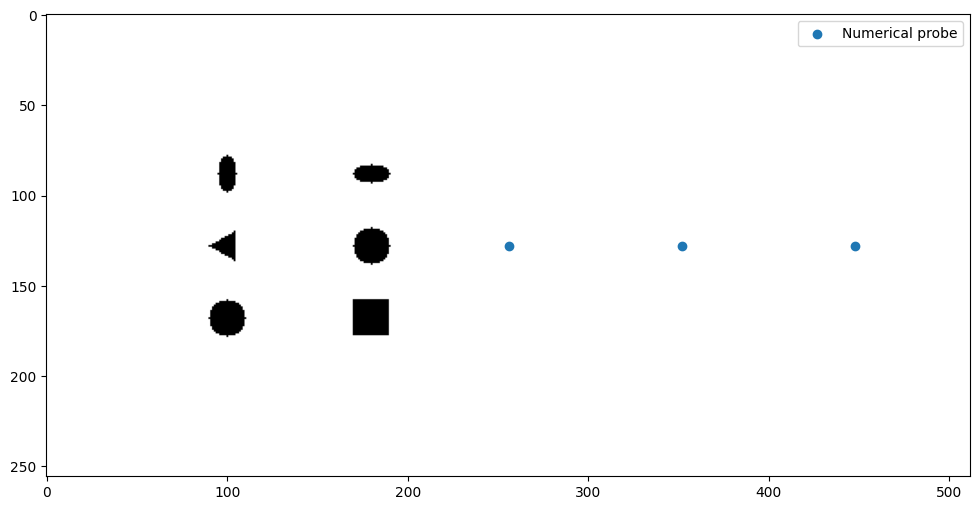

In [14]:
plt.figure(figsize=(15, 6))
plt.imshow(sigma[0,0,:,:].cpu(),cmap='gray_r')
if T_stat == True:
    plt.scatter(p_x,p_y,label='Numerical probe')
    plt.legend()

In [15]:
from matplotlib.animation import FuncAnimation
import tqdm
# Import xm for TPU operations if available
if 'xla' in str(device):
    import torch_xla.core.xla_model as xm

@torch.no_grad()
def animate(frame):
    global values_u,values_v,values_p,w,r
    itime = int(frame)
    # advance the model one timestep for this frame (no prints here to avoid duplicates)
    [values_u,values_v,values_p,w,r] = AI4CFD(values_u,values_uu,values_v,values_vv,values_p,values_pp,sigma,b_uu,b_vv,dt,iteration)
    # after [values_u,values_v,values_p,w,r] = AI4CFD(...)
    # move small checks to CPU for readable prints
    max_u = float(values_u.abs().max().cpu())
    max_w = float(w.abs().max().cpu())
    nan_u = torch.isnan(values_u).any().item()
    if nan_u or np.isinf(max_u) or np.isnan(max_u):
        print(f'ERROR: NaN/Inf in u at it={itime}, max_u={max_u}')
        np.save(filepath+f"/u_fail_{itime}.npy", values_u.cpu().detach().numpy())
        raise RuntimeError('Numerical blow-up: NaN/Inf encountered')

    # CFL estimate (for guidance)
    max_speed = max_u
    cfl = max_speed * dt / dx
    if cfl > 0.5:
        print(f'Warning: CFL high = {cfl:.3f} at it={itime} (reduces stability)')

    # Optionally clamp or nan-to-num to avoid saving bad frames
    if max_w > 1e6 or max_u > 1e6:
        print(f'Blow-up detected at it={itime}: max_u={max_u:.3g}, max_w={max_w:.3g}; saving and stopping.')
        np.save(filepath+f"/u_bad_{itime}.npy", values_u.cpu().detach().numpy())
        # either stop or clamp as emergency:
        values_u = torch.nan_to_num(values_u, nan=0.0, posinf=1e6, neginf=-1e6)
        # then break/raise to avoid continuing a broken run
        raise RuntimeError('Numerical blow-up (large values)')
    # For TPU, mark the step to execute operations
    if 'xla' in str(device):
        xm.mark_step()

    # check divergence / residual and stop updating the image if not converged
    if np.max(np.abs(w.cpu().detach().numpy())) > 80000.0: # .cpu() for residual check
        return
    
    # probing
    if T_stat:
        for k in range(N_p):
            # Ensure tensor is on CPU before accessing specific elements for numpy conversion
            num_p[k,itime-1] = values_u[0,0,p_y[k],p_x[k]].cpu()

    #save data
    if L_save and itime % n_out == 0:
            np.save(filepath+"/u"+str(itime), arr=values_u.cpu().detach().numpy())
            np.save(filepath+"/v"+str(itime), arr=values_v.cpu().detach().numpy()) 
            #np.save(filepath+"/p"+str(itime), arr=values_p.cpu().detach().numpy()) 

print("======================================================================")
print("Welcome to AI4CFD solver that will generate flow past a block for you!")
print("======================================================================")
print("Summarising basic numerical setup before running AI4CFD code..........")
print(f'inflow speed from left to right --- {-ub} (m/s)')
print(f'Time step ------------------------- {dt} (s)')
print(f'Grid size ------------------------- {dx} (m)')
print(f'block size ------------------------ {size_x*2} (m)')
print(f'Reynolds number ------------------- {-ub*size_x*2/nu} (-)')
if T_stat:
    print("You are saving time series results!")
if L_save:
    print("You are saving spatial results!")
print("======================================================================")
print("Hello World, AI4CFD is running now!")

# Run timesteps directly with tqdm (no FuncAnimation) and call animate for each frame
start = time.time()
with tqdm.tqdm(total=ntime, desc='Running timesteps') as pbar:
    for it in range(1, ntime+1):
        animate(it)  # calls AI4CFD and handles probing/saving inside animate
        pbar.update(1)
end = time.time()

print('Elapsed time:', end - start)

print('Elapsed time:', end - start)


ModuleNotFoundError: No module named 'tqdm'

In [ ]:
plt.figure(figsize=(15, 10))
for i in range(N_p):
    plt.subplot(N_p,1,i+1)
    plt.plot(num_p[i,:],label=f'Numerical proble {i+1}')
    plt.legend()
    plt.xlabel('Time step')
    plt.ylabel('u velocity (m/s)')

In [ ]:
from matplotlib import animation

def save(filepath, n_t, save_filename,
         sigma_tensor=sigma, # Pass your global sigma
         var="u",
         dt=10,
         clip_percentile=99,
         clip_multiplier=1.5,
         cmap='RdBu_r'):

    fig = plt.figure(figsize=(15, 10))

    # --- 1. Prepare Colormap ---
    current_cmap = plt.get_cmap(cmap).copy()
    current_cmap.set_bad(color='black')  # This makes masked pixels black

    # --- 2. Prepare Mask ---
    # Ensure sigma is on CPU and numpy
    if hasattr(sigma_tensor, 'detach'):
        sigma_np = sigma_tensor.detach().cpu().numpy()
    else:
        sigma_np = sigma_tensor
        
    obstacle_mask = sigma_np[0, 0, :, :] > 0

    # --- 3. Compute Contrast ---
    n_sample = min(10, max(1, n_t))
    samples = []
    for i in range(n_sample):
        s = np.load(f"{filepath}/{var}{(i+1)*dt}.npy")
        samples.append(s[0, 0, :, :].ravel())
    all_s = np.concatenate(samples)
    clip = np.percentile(np.abs(all_s), clip_percentile)
    clip *= clip_multiplier
    vmin, vmax = -clip, clip

    # --- 4. First Frame ---
    u_t = -np.load(f"{filepath}/{var}{1*dt}.npy")[0, 0, :, :]
    masked_data = np.ma.masked_where(obstacle_mask, u_t)
    
    # FIX 1: Use 'current_cmap', not the string 'cmap'
    im = plt.imshow(masked_data, vmin=vmin, vmax=vmax, cmap=current_cmap, interpolation='nearest')
    plt.colorbar(im, fraction=0.046, pad=0.04)

    # --- 5. Update Loop ---
    def update(t):
        u_t = np.load(f"{filepath}/{var}{(t+1)*dt}.npy")
        raw_data = -u_t[0, 0, :, :]
        
        # FIX 2: Re-apply the mask for every single frame
        masked_frame = np.ma.masked_where(obstacle_mask, raw_data)
        
        im.set_array(masked_frame)
        plt.title(f"Flow at time {t*dt}")
        return (im,)

    ani = animation.FuncAnimation(fig=fig, func=update, frames=n_t-1,
                                  interval=30, blit=True)
    
    # Ensure ffmpeg is installed or switch to PillowWriter if needed
    try:
        writer = animation.FFMpegWriter(fps=60, metadata=dict(artist='Me'), bitrate=1800)
        ani.save(save_filename, writer=writer)
    except FileNotFoundError:
        print("FFmpeg not found. Falling back to Pillow (GIF)...")
        writer = animation.PillowWriter(fps=60)
        ani.save(save_filename.replace('.mp4', '.gif'), writer=writer)
        
    print(f"Animation generated (clip={clip:.3g}).")

In [ ]:
# Example call (uses sampling to compute clip)          var="u", dt=n_out)
save(filepath, n_t=int(ntime/n_out), save_filename=f"AI4CFD_u.mp4", dt=n_out)
save(filepath, n_t=int(ntime/n_out), save_filename=f"AI4CFD_v.mp4", dt=n_out,var="v")
#animate(filepath, n_t=int(ntime/n_out), save_filename=f"AI4CFD_p.gif", dt=n_out,var="p")

In [ ]:
from matplotlib import animation
from matplotlib.colors import hsv_to_rgb
import numpy as np
import matplotlib.pyplot as plt
import torch

def animate_uv(filepath, n_t, save_filename,
               sigma_tensor=sigma,  # Pass global sigma
               var_u="u", var_v="v",
               dt=10,
               clip_percentile=99,
               clip_multiplier=1.5,
               overlay_quiver=False,
               quiver_stride=8):
    
    fig = plt.figure(figsize=(15, 10))

    # --- 1. Prepare Mask (CPU/Numpy) ---
    if hasattr(sigma_tensor, 'detach'):
        sigma_np = sigma_tensor.detach().cpu().numpy()
    else:
        sigma_np = sigma_tensor
    # Boolean mask: (ny, nx)
    obstacle_mask = sigma_np[0, 0, :, :] > 0

    # --- 2. Compute Clip ---
    n_sample = min(10, max(1, n_t))
    samples = []
    for i in range(n_sample):
        uu = np.load(f"{filepath}/{var_u}{(i+1)*dt}.npy")[0,0,:,:]
        vv = np.load(f"{filepath}/{var_v}{(i+1)*dt}.npy")[0,0,:,:]
        speed = np.sqrt(uu**2 + vv**2)
        samples.append(speed.ravel())
    all_s = np.concatenate(samples)
    clip = np.percentile(all_s, clip_percentile)
    clip *= clip_multiplier
    clip = max(1e-12, clip)

    # --- 3. First Frame ---
    uu = -np.load(f"{filepath}/{var_u}{1*dt}.npy")[0,0,:,:]
    vv = -np.load(f"{filepath}/{var_v}{1*dt}.npy")[0,0,:,:]
    
    speed = np.sqrt(uu**2 + vv**2)
    speed_n = np.clip(speed / clip, 0.0, 1.0)
    angle = np.arctan2(vv, uu)
    hue = (angle + np.pi) / (2 * np.pi)

    hsv = np.stack([hue, speed_n, speed_n], axis=-1)
    rgb = hsv_to_rgb(hsv)
    
    # --- PAINT IT WHITE ---
    # Set pixels where mask is True to White [1, 1, 1]
    rgb[obstacle_mask, :] = 1.0 

    im = plt.imshow(rgb, interpolation='nearest')
    plt.title('Combined u/v (hue=direction, brightness=magnitude)')

    # Optional quiver
    quiv = None
    if overlay_quiver:
        ny, nx = uu.shape
        ys = np.arange(0, ny, quiver_stride)
        xs = np.arange(0, nx, quiver_stride)
        X, Y = np.meshgrid(xs, ys)
        U = uu[::quiver_stride, ::quiver_stride]
        V = vv[::quiver_stride, ::quiver_stride]
        quiv = plt.quiver(X, Y, U, V, color='k', scale=10)

    # --- 4. Update Loop ---
    def update(t):
        uu = -np.load(f"{filepath}/{var_u}{(t+1)*dt}.npy")[0,0,:,:]
        vv = -np.load(f"{filepath}/{var_v}{(t+1)*dt}.npy")[0,0,:,:]
        
        speed = np.sqrt(uu**2 + vv**2)
        speed_n = np.clip(speed / clip, 0.0, 1.0)
        angle = np.arctan2(vv, uu)
        hue = (angle + np.pi) / (2 * np.pi)
        
        hsv = np.stack([hue, speed_n, speed_n], axis=-1)
        rgb = hsv_to_rgb(hsv)
        
        # Apply White Mask again for every frame
        rgb[obstacle_mask, :] = 1.0 
        
        im.set_data(rgb)
        
        if overlay_quiver and quiv is not None:
            U = uu[::quiver_stride, ::quiver_stride]
            V = vv[::quiver_stride, ::quiver_stride]
            quiv.set_UVC(U, V)
            return (im, quiv)
        return (im,)

    ani = animation.FuncAnimation(fig=fig, func=update, frames=n_t-1,
                                  interval=30, blit=True)
    
    # Save (switch to PillowWriter if ffmpeg fails)
    try:
        writer = animation.FFMpegWriter(fps=60, metadata=dict(artist='Me'), bitrate=1800)
        ani.save(save_filename, writer=writer)
    except FileNotFoundError:
        print("FFmpeg not found. Falling back to GIF...")
        writer = animation.PillowWriter(fps=60)
        ani.save(save_filename.replace('.mp4', '.gif'), writer=writer)
        
    print(f"Animation generated and saved as {save_filename} (clip={clip:.3g}).")


def preview_uv_frame(filepath, sigma_tensor=sigma, frame=1, var_u='u', var_v='v', dt=10, clip_multiplier=1.5):
    # Prepare Mask
    if hasattr(sigma_tensor, 'detach'):
        sigma_np = sigma_tensor.detach().cpu().numpy()
    else:
        sigma_np = sigma_tensor
    obstacle_mask = sigma_np[0, 0, :, :] > 0

    # Load Data
    uu = -np.load(f"{filepath}/{var_u}{frame*dt}.npy")[0,0,:,:]
    vv = -np.load(f"{filepath}/{var_v}{frame*dt}.npy")[0,0,:,:]
    
    speed = np.sqrt(uu**2 + vv**2)
    clip = np.percentile(np.abs(speed).ravel(), 99) * clip_multiplier
    speed_n = np.clip(speed / clip, 0.0, 1.0)
    angle = np.arctan2(vv, uu)
    hue = (angle + np.pi) / (2 * np.pi)
    
    hsv = np.stack([hue, speed_n, speed_n], axis=-1)
    rgb = hsv_to_rgb(hsv)
    
    # Apply White Mask to RGB
    rgb[obstacle_mask, :] = 1.0

    fig, axs = plt.subplots(1, 2, figsize=(12,5))
    
    # Plot RGB
    axs[0].imshow(rgb, interpolation='nearest')
    axs[0].set_title('Combined u/v (HSV -> RGB)')
    
    # Plot Speed Magnitude (Scalar)
    # For standard plots, we use masked arrays and set 'bad' color to white
    masked_speed = np.ma.masked_where(obstacle_mask, speed)
    cmap = plt.get_cmap('viridis').copy()
    cmap.set_bad(color='white')
    
    im2 = axs[1].imshow(masked_speed, cmap=cmap)
    axs[1].set_title('Speed magnitude')
    plt.colorbar(im2, ax=axs[1])
    
    plt.show()

preview_uv_frame(filepath, frame=1, var_u='u', var_v='v', dt=n_out)
animate_uv(filepath=filepath,save_filename=f"AI4CFD_flow_uv3.mp4", var_u='u', var_v='v', dt=n_out,n_t=int(ntime/n_out))